### Initialise

In [30]:
import numpy as np
import torch
from huggingface_hub import notebook_login
from datasets import load_dataset, load_metric 
from transformers import (AutoFeatureExtractor,
    AutoModelForImageClassification, 
    TrainingArguments, 
    Trainer,
    pipeline,
    AdamW,
    get_scheduler,
  set_seed
)
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)
from PIL import Image
import requests
import matplotlib.pyplot as plt
from pynvml import *
from sam import SAM, SAM_old
import random
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import wandb

In [31]:
torch.cuda.empty_cache() #Clear GPU memory

In [32]:
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)
set_seed(0)

### Load Dataset

In [4]:
model_checkpoint = "WinKawaks/vit-tiny-patch16-224"
batch_size=32

In [5]:
#Load dataset - RESISC45
dataset = load_dataset("imagefolder", data_dir="NWPU-RESISC45_original")

Resolving data files:   0%|          | 0/31500 [00:00<?, ?it/s]

Using custom data configuration default-c97aeb8aa5f5773e
Reusing dataset imagefolder (/home/jeevan/.cache/huggingface/datasets/imagefolder/default-c97aeb8aa5f5773e/0.0.0/48efdc62d40223daee675ca093d163bcb6cb0b7d7f93eb25aebf5edca72dc597)


  0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[21]

'lake'

In [7]:
feature_extractor = AutoFeatureExtractor.from_pretrained(model_checkpoint)
feature_extractor

ViTFeatureExtractor {
  "do_normalize": true,
  "do_resize": true,
  "feature_extractor_type": "ViTFeatureExtractor",
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "size": 224
}

In [8]:
normalize = Normalize(mean = feature_extractor.image_mean, std = feature_extractor.image_std)

transforms = Compose(
        [
            Resize(feature_extractor.size),
            ToTensor()
        ])

def preprocess(batch):
    """Apply transforms across a batch."""
    batch["pixel_values"] = [
        transforms(image.convert("RGB")) for image in batch["image"] 
    ]
    return batch

In [9]:
dataset["train"].set_transform(preprocess)

#Split the training set into train + validation
splits = dataset["train"].train_test_split(test_size = 0.1, seed=0)
train_ds = splits["train"]
val_ds = splits["test"]
#If conducting augmentations, the set_transform would go after splitting the dataset - one for train, one for val

Parameter 'transform'=<function preprocess at 0x7f1bf12527a0> of the transform datasets.arrow_dataset.Dataset.set_format couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.
Loading cached split indices for dataset at /home/jeevan/.cache/huggingface/datasets/imagefolder/default-c97aeb8aa5f5773e/0.0.0/48efdc62d40223daee675ca093d163bcb6cb0b7d7f93eb25aebf5edca72dc597/cache-dc1307daab9b8135.arrow and /home/jeevan/.cache/huggingface/datasets/imagefolder/default-c97aeb8aa5f5773e/0.0.0/48efdc62d40223daee675ca093d163bcb6cb0b7d7f93eb25aebf5edca72dc597/cache-07c69933d5d366ad.arrow


In [10]:
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [11]:
train_dataloader = DataLoader(
        train_ds, shuffle=True, batch_size=batch_size, collate_fn=collate_fn
)

eval_dataloader = DataLoader(
        val_ds, batch_size=batch_size, collate_fn=collate_fn
)

In [12]:
#Split dataset further - create a dataloader with just one image.
splits = val_ds.train_test_split(test_size = 0.000317, seed=0)
loss_ds = splits['test']
loss_dl = DataLoader(
loss_ds, batch_size=1, collate_fn=collate_fn)

In [13]:
#Check that the dataloader only contains a single batch (of batch size one)
#Also check that it is the same image
#First pixel value in tensor (top left) is 0.1529 and label is 40
for batch in loss_dl:
    print(batch)

{'pixel_values': tensor([[[[0.1529, 0.2549, 0.2000,  ..., 0.1765, 0.2000, 0.2431],
          [0.2353, 0.3451, 0.3765,  ..., 0.2078, 0.2118, 0.2510],
          [0.3843, 0.4078, 0.4588,  ..., 0.3608, 0.3294, 0.3961],
          ...,
          [0.4863, 0.5020, 0.5020,  ..., 0.2196, 0.2235, 0.2431],
          [0.4824, 0.4980, 0.4941,  ..., 0.2314, 0.2275, 0.2471],
          [0.5333, 0.5176, 0.5176,  ..., 0.2353, 0.2314, 0.2510]],

         [[0.1255, 0.2275, 0.1725,  ..., 0.1333, 0.1569, 0.2000],
          [0.2078, 0.3216, 0.3490,  ..., 0.1647, 0.1725, 0.2078],
          [0.3647, 0.3922, 0.4392,  ..., 0.3255, 0.2941, 0.3608],
          ...,
          [0.4314, 0.4510, 0.4471,  ..., 0.1490, 0.1529, 0.1725],
          [0.4235, 0.4431, 0.4392,  ..., 0.1647, 0.1608, 0.1804],
          [0.4745, 0.4588, 0.4588,  ..., 0.1686, 0.1647, 0.1843]],

         [[0.1020, 0.2039, 0.1490,  ..., 0.1490, 0.1725, 0.2157],
          [0.1882, 0.2980, 0.3294,  ..., 0.1765, 0.1882, 0.2235],
          [0.3529, 0.3765

In [64]:
def plot_loss_landscape(model, num_vals=31, pixel_one=[0, 0, 0], pixel_two=[1, 0, 0]):
    """TODO."""
    progress_bar = tqdm(range(num_vals**2)) #Progress bar
    
    model.to("cuda") #Put model on GPU
    
    grid = np.zeros((num_vals, num_vals)) #Create a 2D grid of zeros to fill in with losses
    x = y = np.linspace(0, 1, num_vals) #evenly spaced values between 0 and 1
    X, Y = np.meshgrid(x, y) #For matplotlib 3D surface plot
    
    #Choose which pixels (input parameters) to edit
    # i1 and i2 - RGB channel
    # j1 and j2 - x dimension of image i.e. width
    # k1 and k2 - y dimension of image i.e. height
    i1, j1, k1 = pixel_one[0], pixel_one[1], pixel_one[2]
    i2, j2, k2 = pixel_two[0], pixel_two[1], pixel_two[2]
    
    for i, val1 in enumerate(x):
        for j, val2 in enumerate(y):
            for batch in loss_dl:
                
                batch["pixel_values"][0][i1][j1][k1] = val1 #Change two pixel values of the selected image
                batch["pixel_values"][0][i2][j2][k2] = val2
                batch = {k: v.to("cuda") for k, v in batch.items()} #Put batch onto GPU
                
                outputs = model(**batch) #Get outputs of model for given batch
                loss = outputs.loss #Get losses
                grid[i][j] = loss #Put loss into grid

                progress_bar.update(1) #Update progress bar
                
    #Plot losses as function of two input parameters            
    fig = plt.figure
    ax = plt.axes(projection='3d')
    ax.plot_surface(X, Y, grid, cmap='viridis')

In [65]:
def plot_loss_landscape_sam(model, num_vals=31, pixel_one=[0, 0, 0], pixel_two=[1, 0, 0]):
    """TODO."""
    progress_bar = tqdm(range(num_vals**2)) #Progress bar
    
    #Craete optimizer - we will not actually optimize the model.
    #The SAM optimizer has built in method to perturb (and unperturb) the weights of the model.
    base_optimizer = AdamW
    optimizer = SAM_old(model.parameters(), base_optimizer, lr=5e-5)
    
    model.to("cuda") #Put model on GPU
    
    #Two 2D grids of zeros for losses before and after perturbing, respectively i.e. non-SAM and SAM.
    grid, grid2 = np.zeros((num_vals, num_vals)), np.zeros((num_vals, num_vals))
    x = y = np.linspace(0, 1, num_vals) #101 evenly spaced values between 0 and 1
    X, Y = np.meshgrid(x, y) #For matplotlib 3D surface plot
    
    #Choose which pixels (input parameters) to edit
    # i1 and i2 - RGB channel
    # j1 and j2 - x dimension of image i.e. width
    # k1 and k2 - y dimension of image i.e. height
    i1, j1, k1 = pixel_one[0], pixel_one[1], pixel_one[2]
    i2, j2, k2 = pixel_two[0], pixel_two[1], pixel_two[2]

    for i, val1 in enumerate(x):
        for j, val2 in enumerate(y):
            for batch in loss_dl:
                
                batch["pixel_values"][0][i1][j1][k1] = val1 #Change two pixel values of selected image
                batch["pixel_values"][0][i2][j2][k2] = val2
                batch = {k: v.to("cuda") for k, v in batch.items()} #Put batch onto GPU
                
                outputs = model(**batch) #Get outputs of model for given batch
                loss = outputs.loss #Get losses
                grid[i][j] = loss #Put loss into grid one
                
                #SAM - sharpness aware minimization
                loss.backward() #Gradients
                optimizer.first_step(zero_grad=True) #Perturb weights of model
                outputs2 = model(**batch) #Get output of model for batch based on perturbed weights
                loss2 = outputs2.loss #Update loss based on outputs
                grid2[i][j] = loss2 #Put perturbed loss into grid two
                
                loss2.backward()
                optimizer.unperturb() #Unperturb weights of model
                optimizer.zero_grad() #Set gradient to zero to prevent gradient accumulating
                #We will not conduct the actual update step - do not want to change the model
                
                progress_bar.update(1) #Update progress bar
    
    #Plot unperturbed losses as function of two input parameters
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot_surface(X, Y, grid, cmap='viridis')
    
    #Plot perturbed losses as function of the same two input parameters
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    ax.plot_surface(X, Y, grid2, cmap='viridis')
    plt.show()

# Untrained model

Load ViT Tiny which has been pre-trained on ImageNet, but not finetuned on Resisc45

RUN THIS AFTER EACH LOSS LANDSCAPE VIZ

In [74]:
set_seed(0) #Ensure the randomised classification head is the same each time
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id = label2id,
    id2label = id2label,
    ignore_mismatched_sizes = True, #fine-tuning an already fine-tuned checkpoint
    num_labels = 45
)
torch.cuda.empty_cache() #Clear GPU memory

Some weights of ViTForImageClassification were not initialized from the model checkpoint at WinKawaks/vit-tiny-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([45, 192]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([45]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


0,0,0 and 2,100,10

  0%|          | 0/10201 [00:00<?, ?it/s]

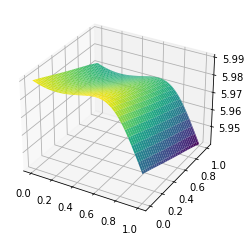

In [38]:
plot_loss_landscape(model, pixel_two = [2, 100, 10])

Reducing num_vals from 101 to 31 - 31 looks fine and massively reduces time! Updated default to 31.

  0%|          | 0/961 [00:00<?, ?it/s]

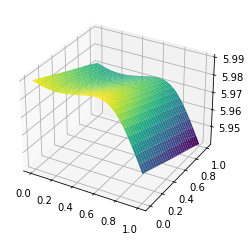

In [50]:
plot_loss_landscape(model, num_vals=31, pixel_two=[2, 100, 10])

  0%|          | 0/961 [00:00<?, ?it/s]

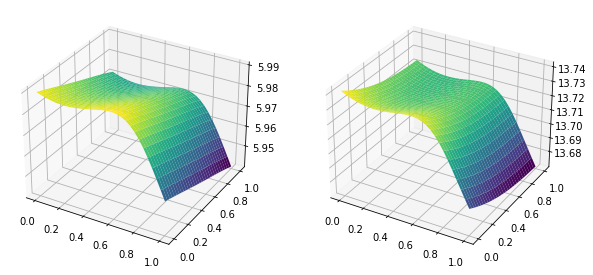

In [63]:
plot_loss_landscape_sam(model, num_vals=31, pixel_two = [2, 100, 10])

1,30,150 and 1,40,150

  0%|          | 0/961 [00:00<?, ?it/s]

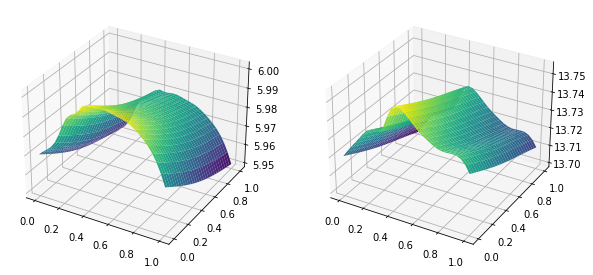

In [70]:
plot_loss_landscape_sam(model, pixel_one=[1, 30, 150], pixel_two=[1, 40, 150])

0, 120, 120 and 0, 121, 121 

  0%|          | 0/961 [00:00<?, ?it/s]

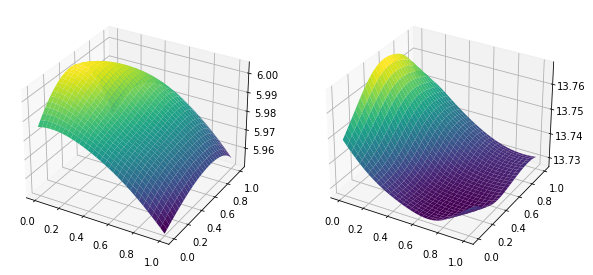

In [71]:
plot_loss_landscape_sam(model, pixel_one=[0, 120, 120], pixel_two=[1, 121, 121])

1, 130, 80 and 2, 130, 80

  0%|          | 0/961 [00:00<?, ?it/s]

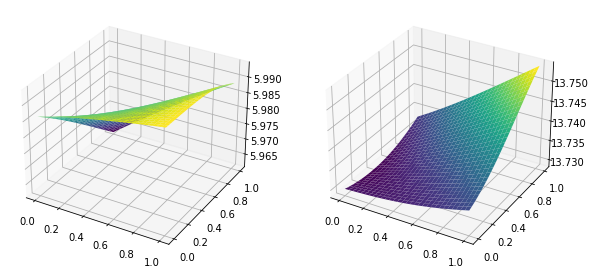

In [73]:
plot_loss_landscape_sam(model, pixel_one=[1, 130, 80], pixel_two=[2, 130, 80])

0, 150, 100 and 2, 160, 90

  0%|          | 0/961 [00:00<?, ?it/s]

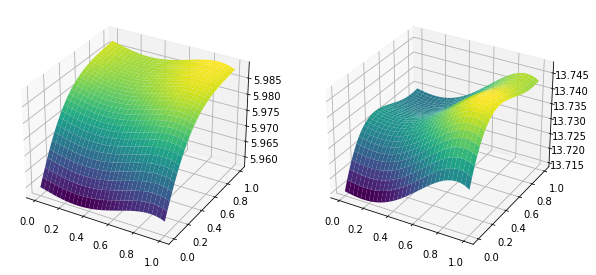

In [75]:
plot_loss_landscape_sam(model, pixel_one=[0, 150, 100], pixel_two=[2, 160, 90])

# Finetuned Model : Non-SAM

Model that did not use SAM, but we will compare non-SAM and SAM losses for this model.

In [76]:
set_seed(0) #Ensure the randomised classification head is the same each time
model_no_sam = AutoModelForImageClassification.from_pretrained(
    "hf_vit_tiny_no-sam",
    label2id = label2id,
    id2label = id2label,
    ignore_mismatched_sizes = False,
    num_labels = 45
)
#The ViT from Google was pre-trained on ImageNet-21k and then fine-tuned on ImageNet 2012. As we are
#fine-tuning on another dataset, we must ignore the old output head and replace it with a new,
#randomly-initialised classification head with a custom number of output neurons, specific to RESISC45

Inference on validation set to check loaded model is working right.

In [79]:
model_no_sam.to("cuda")
metric = load_metric("accuracy") #Load accuracy metric for evaluation
for val_batch in eval_dataloader: #Iterate over validation batches
    val_batch = {k: v.to("cuda") for k, v in val_batch.items()}
    with torch.no_grad():
        outputs = model_no_sam(**val_batch) #Get outputs from model for batch

    logits = outputs.logits #Get logits
    predictions = torch.argmax(logits, dim=-1) #Get pred = argmax of logits
    metric.add_batch(predictions=predictions, references=val_batch["labels"])

acc = metric.compute() #Display metrics
print(acc)

{'accuracy': 0.9511111111111111}


  0%|          | 0/961 [00:00<?, ?it/s]

/home/jeevan/myrtle-vision/classification/venv/lib/python3.10/site-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


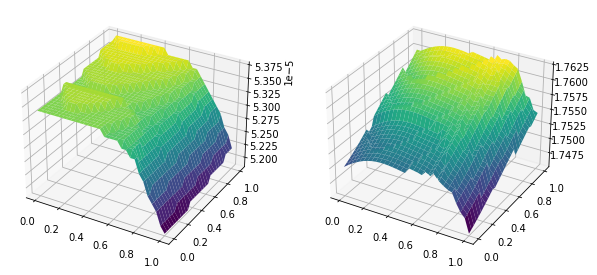

In [80]:
plot_loss_landscape_sam(model_no_sam, pixel_two=[2, 100, 10])

  0%|          | 0/2601 [00:00<?, ?it/s]

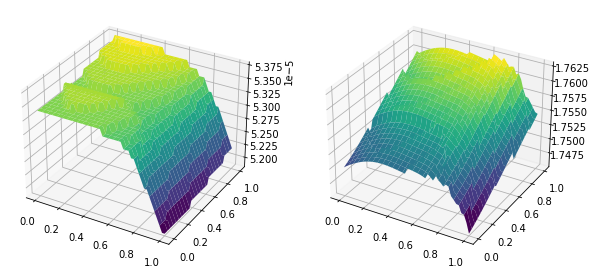

In [81]:
plot_loss_landscape_sam(model_no_sam, num_vals=51, pixel_two=[2, 100, 10])

  0%|          | 0/961 [00:00<?, ?it/s]

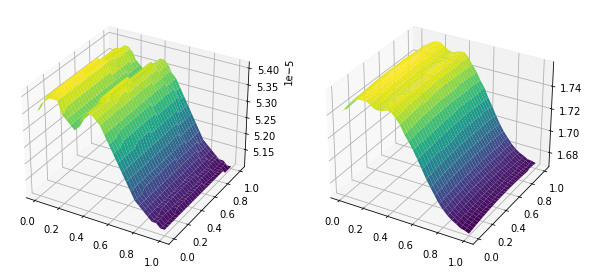

In [82]:
plot_loss_landscape_sam(model_no_sam, pixel_one=[1, 30, 150], pixel_two=[1, 40, 150])

  0%|          | 0/961 [00:00<?, ?it/s]

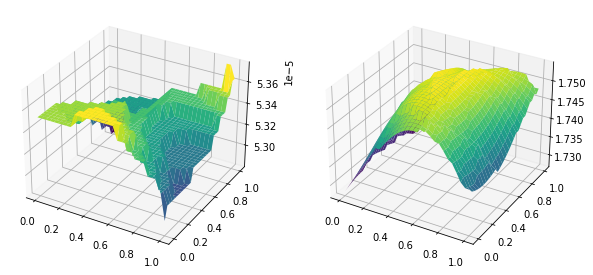

In [83]:
plot_loss_landscape_sam(model_no_sam, pixel_one=[0, 120, 120], pixel_two=[1, 121, 121])

  0%|          | 0/961 [00:00<?, ?it/s]

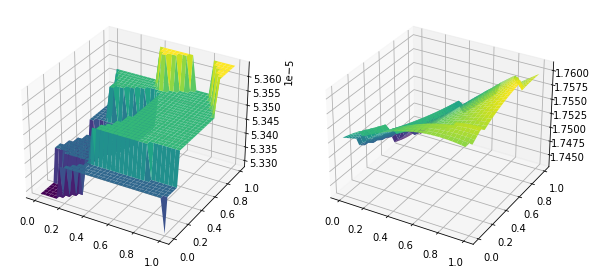

In [84]:
plot_loss_landscape_sam(model_no_sam, pixel_one=[1, 130, 80], pixel_two=[2, 130, 80])

  0%|          | 0/961 [00:00<?, ?it/s]

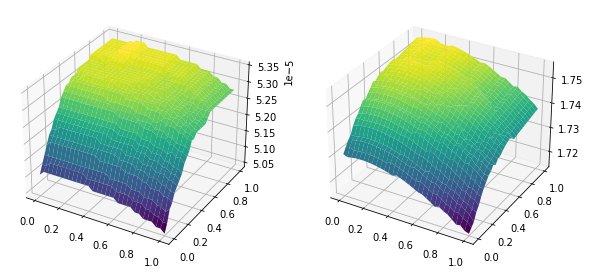

In [85]:
plot_loss_landscape_sam(model_no_sam, pixel_one=[0, 150, 100], pixel_two=[2, 160, 90])

# Finetuned Model : SAM

In [86]:
set_seed(0) #Ensure the randomised classification head is the same each time
model_sam = AutoModelForImageClassification.from_pretrained(
    "hf_vit_tiny_sam",
    label2id = label2id,
    id2label = id2label,
    ignore_mismatched_sizes = False,
    num_labels = 45
)
#The ViT from Google was pre-trained on ImageNet-21k and then fine-tuned on ImageNet 2012. As we are
#fine-tuning on another dataset, we must ignore the old output head and replace it with a new,
#randomly-initialised classification head with a custom number of output neurons, specific to RESISC45

In [87]:
def eval_model(model):
    model.to("cuda")
    metric = load_metric("accuracy") #Load accuracy metric for evaluation
    for val_batch in eval_dataloader: #Iterate over validation batches
        val_batch = {k: v.to("cuda") for k, v in val_batch.items()}
        with torch.no_grad():
            outputs = model(**val_batch) #Get outputs from model for batch

        logits = outputs.logits #Get logits
        predictions = torch.argmax(logits, dim=-1) #Get pred = argmax of logits
        metric.add_batch(predictions=predictions, references=val_batch["labels"])

    acc = metric.compute() #Display metrics
    print(acc)

In [88]:
eval_model(model_sam)

{'accuracy': 0.9565079365079365}


  0%|          | 0/961 [00:00<?, ?it/s]

/home/jeevan/myrtle-vision/classification/venv/lib/python3.10/site-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


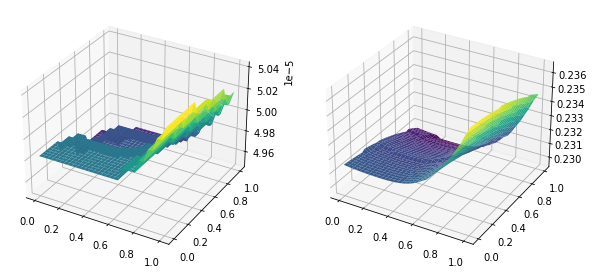

In [89]:
plot_loss_landscape_sam(model_sam, pixel_two=[2, 100, 10])

  0%|          | 0/961 [00:00<?, ?it/s]

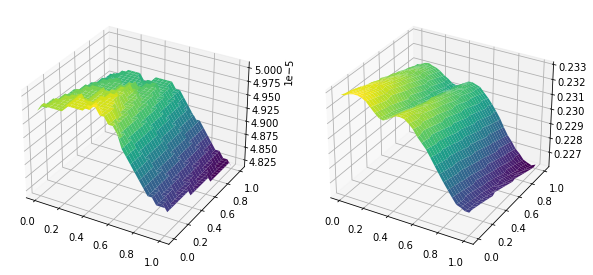

In [90]:
plot_loss_landscape_sam(model_sam, pixel_one=[1, 30, 150], pixel_two=[1, 40, 150])

  0%|          | 0/961 [00:00<?, ?it/s]

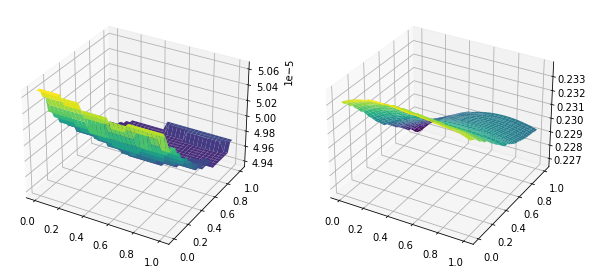

In [91]:
plot_loss_landscape_sam(model_sam, pixel_one=[0, 120, 120], pixel_two=[1, 121, 121])

  0%|          | 0/961 [00:00<?, ?it/s]

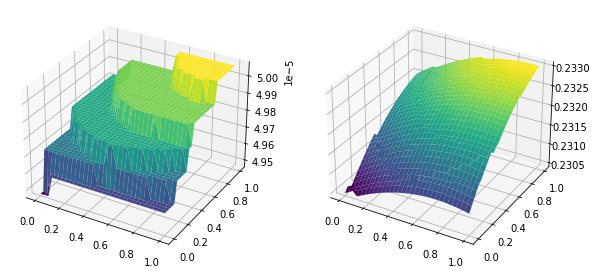

In [92]:
plot_loss_landscape_sam(model_sam, pixel_one=[1, 130, 80], pixel_two=[2, 130, 80])

  0%|          | 0/961 [00:00<?, ?it/s]

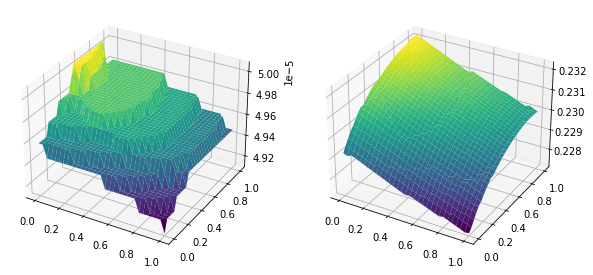

In [93]:
plot_loss_landscape_sam(model_sam, pixel_one=[0, 150, 100], pixel_two=[2, 160, 90])